# Simple E-I Pop



In [1]:
import numpy as np
import pandas as pd
import nest
import nest.raster_plot
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sim_utils import *


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: May 24 2024 10:11:53

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



# Simulation Set UP

In [2]:
def sim(sim_params, neuron_dicts, syn_params, current_params):
    nest.ResetKernel()
    # Make simulation with higher resolution
    nest.SetKernelStatus({"resolution": 1})

    # Create AdEx neuron
    neuron1 = nest.Create("aeif_cond_exp", n=sim_params["n_ex"], params=neuron_dicts["TC"])
    neuron2 = nest.Create("aeif_cond_exp", n=sim_params["n_inh"], params=neuron_dicts["RE"])

    # Create a poisson generator
    step_current = nest.Create("step_current_generator", params=current_params)

    #sni
    #  Connect the step current generator to the neuron
    #nest.Connect(step_current, neuron1)
    nest.Connect(step_current, neuron1)
    nest.Connect(neuron1, neuron2, "all_to_all",syn_spec={'weight': syn_params["w_e"]})
    nest.Connect(neuron2, neuron1, "all_to_all",syn_spec={'weight': syn_params["w_i"]})

    # Create a voltmeter to record the membrane potential
    voltmeter1 = nest.Create("voltmeter")
    voltmeter2 = nest.Create("voltmeter")
    spikemeter1 = nest.Create("spike_recorder")
    spikemeter2 = nest.Create("spike_recorder")

    # Connect the voltmeter to the neuron
    nest.Connect(voltmeter1, neuron1)
    nest.Connect(voltmeter2, neuron2)

    nest.Connect(neuron1, spikemeter1) # TC
    nest.Connect(neuron2, spikemeter2) # RE

    nest.Simulate(1000.0)

    return {
        "voltmeters": [voltmeter1, voltmeter2],
        "spikemeters": [spikemeter1, spikemeter2]
    }




# Simulate Initial State

In [3]:
data = {
    "neuron_type": [ "TC", "RE"],
    "C_m": [1250, 1250], # pF
    "t_ref": [ 2.5, 2.5], # ms
    "E_L": [ -60, -60], # mV
    "Delta_T": [ 2.5, 2.5], # mV
    "V_th": [ -55, -50], # mV
    "V_reset": [ -60, -60],    
    "g_L": [ 50, 50],
    "a": [ 300, 400], # nS
    "b": [ 0, 20], # pA
    "tau_w": [ 600, 600],
    "I_e": [ 0, 0],
    "V_m": [ -60, -60],
    "V_peak": [20,20],# mV
    "I_e": [0,0],               # pA
    "V_m": [-60.0,-60.0],
    "tau_syn_ex": [ 5, 5],
    "tau_syn_in": [ 20, 20],
}

current_params = { "amplitude_times": [50, 100], "amplitude_values": [1000, 0.0]}

neuron_dicts = create_neuron_dicts(data)

sim_params = {
    "resolution": 0.001,
    "simtime": 1000.0,
    "n_inh": 1,
    "n_ex": 1,
}
syn_params = {
    "w_e": 700.0,  # weight of excitatory connection in nS
    "w_i": -1000.0,  # weight of inhibitory connection in nS
}

sim_output = sim(sim_params, neuron_dicts, syn_params, current_params)


Feb 12 17:20:02 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:02 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:02 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Feb 12 17:20:02 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.

Feb 12 17:20:02 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Feb 12 17:20:02 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Feb 12 17:20:02 SimulationManager::run [Info]: 
    Simulation finished.


# Plot Inital State


Feb 12 17:20:02 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:02 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:02 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Feb 12 17:20:02 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.

Feb 12 17:20:02 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Feb 12 17:20:02 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Feb 12 17:20:02 SimulationManager::run [Info]: 
    Simulation finished.


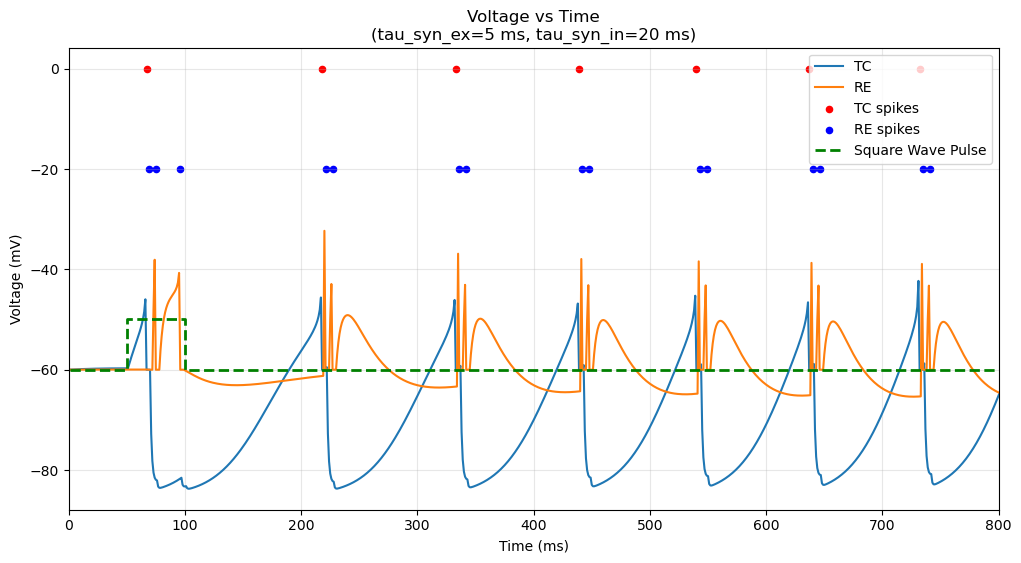

TC (Excitatory) Population Analysis:
Number of spikes: 9
Number of bursts: 0
Intra-burst ISI: mean=nanms, std=nanms
Inter-burst ISI: mean=99.71ms, std=7.80ms

RE (Inhibitory) Population Analysis:
Number of spikes: 19
Number of bursts: 8
Intra-burst ISI: mean=6.00ms, std=0.00ms
Inter-burst ISI: mean=93.71ms, std=7.80ms


/home/eris/miniconda3/envs/neuro_sim/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:Mean of empty slice.
/home/eris/miniconda3/envs/neuro_sim/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning:invalid value encountered in scalar divide
/home/eris/miniconda3/envs/neuro_sim/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning:Degrees of freedom <= 0 for slice
/home/eris/miniconda3/envs/neuro_sim/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning:invalid value encountered in divide
/home/eris/miniconda3/envs/neuro_sim/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning:invalid value encountered in scalar divide


In [4]:
data = {
    "neuron_type": [ "TC", "RE"],
    "C_m": [1250, 1250], # pF
    "t_ref": [ 2.5, 2.5], # ms
    "E_L": [ -60, -60], # mV
    "Delta_T": [ 2.5, 2.5], # mV
    "V_th": [ -55, -50], # mV
    "V_reset": [ -60, -60],    
    "g_L": [ 50, 50],
    "a": [ 300, 400], # nS
    "b": [ 0, 20], # pA
    "tau_w": [ 600, 600],
    "I_e": [ 0, 0],
    "V_m": [ -60, -60],
    "V_peak": [20,20],# mV
    "I_e": [0,0],               # pA
    "V_m": [-60.0,-60.0],
    "tau_syn_ex": [ 5, 5],
    "tau_syn_in": [ 20, 20],
}

current_params = { "amplitude_times": [50, 100], "amplitude_values": [1000, 0.0]}

neuron_dicts = create_neuron_dicts(data)

sim_params = {
    "resolution": 0.001,
    "simtime": 1000.0,
    "n_inh": 1,
    "n_ex": 1,
}
syn_params = {
    "w_e": 700.0,  # weight of excitatory connection in nS
    "w_i": -1000.0,  # weight of inhibitory connection in nS
}

sim_output = sim(sim_params, neuron_dicts, syn_params, current_params)


# Fix variable assignments - spikemeters should reference spikemeters, not voltmeters
voltmeter1 = sim_output["voltmeters"][0]
voltmeter2 = sim_output["voltmeters"][1]  # Assuming you have a second voltmeter
spikemeter1 = sim_output["spikemeters"][0]  # Fix: should be spikemeters
spikemeter2 = sim_output["spikemeters"][1]  # Fix: should be spikemeters

# Get data once
plot_data_1 = nest.GetStatus(voltmeter1)[0]
plot_data_2 = nest.GetStatus(voltmeter2)[0]
plot_data_3 = nest.GetStatus(spikemeter1)[0]
plot_data_4 = nest.GetStatus(spikemeter2)[0]

times = plot_data_1["events"]["times"]
voltages = plot_data_1["events"]["V_m"]
times2 = plot_data_2["events"]["times"]
voltages2 = plot_data_2["events"]["V_m"]

# Extract spike times and ids
spike_times1 = plot_data_3["events"]["times"]
spike_ids1 = plot_data_3["events"]["senders"]
spike_times2 = plot_data_4["events"]["times"]
spike_ids2 = plot_data_4["events"]["senders"]

# Create single clean plot
plt.figure(figsize=(12, 6))

plt.plot(times, voltages, label="TC", linewidth=1.5)
plt.plot(times2, voltages2, label="RE", linewidth=1.5)
plt.scatter(spike_times1, [0]*len(spike_times1), color="red", label="TC spikes", s=20)
plt.scatter(spike_times2, [-20]*len(spike_times2), color="blue", label="RE spikes", s=20)

# Add square wave pulse
pulse_start = 50
pulse_end = 100
pulse_height = 10

pulse_times = [times[0], pulse_start, pulse_start, pulse_end, pulse_end, times[-1]]
pulse_voltages = [voltages[0], voltages[0], voltages[0] + pulse_height, voltages[0] + pulse_height, voltages[0], voltages[0]]

plt.plot(pulse_times, pulse_voltages, label="Square Wave Pulse", linestyle="--", color="green", linewidth=2)

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title(f"Voltage vs Time\n(tau_syn_ex={neuron_dicts['TC']['tau_syn_ex']} ms, tau_syn_in={neuron_dicts['RE']['tau_syn_in']} ms)")
plt.xlim(0, 800)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Get spike data from the meters
spikes1 = spikemeter1.get("events")["times"]  # TC (excitatory) spikes
spikes2 = spikemeter2.get("events")["times"]  # RE (inhibitory) spikes

def analyze_isi_with_bursts(spike_times, burst_threshold=50, ignore_start=100.0):
    """
    Analyze ISI with burst detection
    burst_threshold: max ISI within a burst (ms)
    ignore_start: ignore spikes before this time (ms)
    """
    # Filter out spikes before ignore_start
    spike_times = np.array(spike_times)
    spike_times = spike_times[spike_times >= ignore_start]
    if len(spike_times) < 2:
        return {"intra_burst_isi": [], "inter_burst_isi": [], "burst_info": []}
    
    isis = np.diff(spike_times)
    intra_burst_isi = []
    inter_burst_isi = []
    burst_info = []
    
    current_burst = [spike_times[0]]
    
    for i, isi in enumerate(isis):
        if isi <= burst_threshold:
            # Part of current burst
            current_burst.append(spike_times[i+1])
            intra_burst_isi.append(isi)
        else:
            # End of burst, start new one
            if len(current_burst) > 1:
                burst_info.append({
                    'start_time': current_burst[0],
                    'end_time': current_burst[-1],
                    'spike_count': len(current_burst),
                    'duration': current_burst[-1] - current_burst[0]
                })
            inter_burst_isi.append(isi)
            current_burst = [spike_times[i+1]]
    
    # Handle last burst
    if len(current_burst) > 1:
        burst_info.append({
            'start_time': current_burst[0],
            'end_time': current_burst[-1],
            'spike_count': len(current_burst),
            'duration': current_burst[-1] - current_burst[0]
        })
    
    return {
        "intra_burst_isi": np.array(intra_burst_isi),
        "inter_burst_isi": np.array(inter_burst_isi),
        "burst_info": burst_info
    }

# Analyze TC (excitatory) population
tc_analysis = analyze_isi_with_bursts(spikes1)
print("TC (Excitatory) Population Analysis:")
print(f"Number of spikes: {len(spikes1)}")
print(f"Number of bursts: {len(tc_analysis['burst_info'])}")
print(f"Intra-burst ISI: mean={np.mean(tc_analysis['intra_burst_isi']):.2f}ms, std={np.std(tc_analysis['intra_burst_isi']):.2f}ms")
print(f"Inter-burst ISI: mean={np.mean(tc_analysis['inter_burst_isi']):.2f}ms, std={np.std(tc_analysis['inter_burst_isi']):.2f}ms")

# Analyze RE (inhibitory) population  
re_analysis = analyze_isi_with_bursts(spikes2)
print("\nRE (Inhibitory) Population Analysis:")
print(f"Number of spikes: {len(spikes2)}")
print(f"Number of bursts: {len(re_analysis['burst_info'])}")
print(f"Intra-burst ISI: mean={np.mean(re_analysis['intra_burst_isi']):.2f}ms, std={np.std(re_analysis['intra_burst_isi']):.2f}ms")
print(f"Inter-burst ISI: mean={np.mean(re_analysis['inter_burst_isi']):.2f}ms, std={np.std(re_analysis['inter_burst_isi']):.2f}ms")


In [5]:
tc_analysis["inter_burst_isi_means"]

KeyError: 'inter_burst_isi_means'

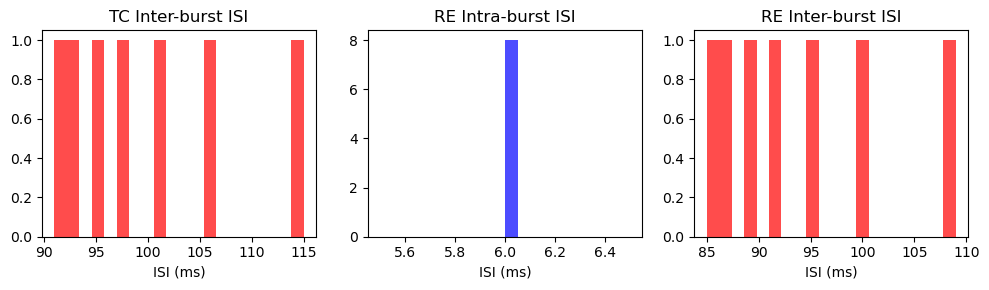

In [6]:

# Plot ISI distributions
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

if len(tc_analysis['inter_burst_isi']) > 0:
    axes[0].hist(tc_analysis['inter_burst_isi'], bins=20, alpha=0.7, color='red')
    axes[0].set_title('TC Inter-burst ISI')
    axes[0].set_xlabel('ISI (ms)')

# RE ISI plots
if len(re_analysis['intra_burst_isi']) > 0:
    axes[1].hist(re_analysis['intra_burst_isi'], bins=20, alpha=0.7, color='blue')
    axes[1].set_title('RE Intra-burst ISI')
    axes[1].set_xlabel('ISI (ms)')

if len(re_analysis['inter_burst_isi']) > 0:
    axes[2].hist(re_analysis['inter_burst_isi'], bins=20, alpha=0.7, color='red')
    axes[2].set_title('RE Inter-burst ISI')
    axes[2].set_xlabel('ISI (ms)')

plt.tight_layout()
plt.show()



In [7]:
# Sweep inhibitory weight (w_i) and analyze ISI (inter- and intra-burst) for both TC and RE for each value

w_i_values = np.linspace(0, 1000, 20)
tc_inter_burst_isi_means = []
tc_intra_burst_isi_means = []
tc_inter_burst_isi_stds = []
tc_intra_burst_isi_stds = []

re_inter_burst_isi_means = []
re_intra_burst_isi_means = []
re_inter_burst_isi_stds = []
re_intra_burst_isi_stds = []

sim_params["duration"] = 2000.0  # Set simulation duration

for w_i in w_i_values:
    syn_params_sweep = syn_params.copy()
    syn_params_sweep["w_i"] = w_i * -1.0  # Inhibitory weight (negative for inhibitory connections)
    sim_output = sim(sim_params, neuron_dicts, syn_params_sweep, current_params)
    spikemeter1 = sim_output["spikemeters"][0] # TC
    spikemeter2 = sim_output["spikemeters"][1] # RE
    spikes1 = spikemeter1.get("events")["times"]
    spikes2 = spikemeter2.get("events")["times"]
    tc_analysis = analyze_isi_with_bursts(spikes1)
    re_analysis = analyze_isi_with_bursts(spikes2)
    # TC
    if len(tc_analysis["inter_burst_isi"]) > 0:
        tc_inter_burst_isi_means.append(np.mean(tc_analysis["inter_burst_isi"]))
        tc_inter_burst_isi_stds.append(np.std(tc_analysis["inter_burst_isi"]))
    else:
        tc_inter_burst_isi_means.append(np.nan)
        tc_inter_burst_isi_stds.append(np.nan)
    if len(tc_analysis["intra_burst_isi"]) > 0:
        tc_intra_burst_isi_means.append(np.mean(tc_analysis["intra_burst_isi"]))
        tc_intra_burst_isi_stds.append(np.std(tc_analysis["intra_burst_isi"]))
    else:
        tc_intra_burst_isi_means.append(np.nan)
        tc_intra_burst_isi_stds.append(np.nan)
    # RE
    if len(re_analysis["inter_burst_isi"]) > 0:
        re_inter_burst_isi_means.append(np.mean(re_analysis["inter_burst_isi"]))
        re_inter_burst_isi_stds.append(np.std(re_analysis["inter_burst_isi"]))
    else:
        re_inter_burst_isi_means.append(np.nan)
        re_inter_burst_isi_stds.append(np.nan)
    if len(re_analysis["intra_burst_isi"]) > 0:
        re_intra_burst_isi_means.append(np.mean(re_analysis["intra_burst_isi"]))
        re_intra_burst_isi_stds.append(np.std(re_analysis["intra_burst_isi"]))
    else:
        re_intra_burst_isi_means.append(np.nan)
        re_intra_burst_isi_stds.append(np.nan)





Feb 12 17:20:03 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:03 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:03 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Feb 12 17:20:03 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.

Feb 12 17:20:03 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Feb 12 17:20:03 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Feb 12 17:20:03 SimulationManager::run [Info]: 
    Simulation finished.

Feb 12 17:20:03 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:03 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:03 correlospinmatrix_detector [Info]: 
    D

In [8]:
# Sweep inhibitory weight (w_i) and analyze ISI (inter- and intra-burst) for both TC and RE for each value

w_e_values = np.linspace(0, 1000, 20)
tc_inter_burst_isi_means = []
tc_intra_burst_isi_means = []
tc_inter_burst_isi_stds = []
tc_intra_burst_isi_stds = []

re_inter_burst_isi_means = []
re_intra_burst_isi_means = []
re_inter_burst_isi_stds = []
re_intra_burst_isi_stds = []

sim_params["duration"] = 2000.0  # Set simulation duration

for w_e in w_e_values:
    syn_params_sweep = syn_params.copy()
    syn_params_sweep["w_e"] = w_e
    sim_output = sim(sim_params, neuron_dicts, syn_params_sweep, current_params)
    spikemeter1 = sim_output["spikemeters"][0] # TC
    spikemeter2 = sim_output["spikemeters"][1] # RE
    spikes1 = spikemeter1.get("events")["times"]
    spikes2 = spikemeter2.get("events")["times"]
    tc_analysis = analyze_isi_with_bursts(spikes1)
    re_analysis = analyze_isi_with_bursts(spikes2)
    # TC
    if len(tc_analysis["inter_burst_isi"]) > 0:
        tc_inter_burst_isi_means.append(np.mean(tc_analysis["inter_burst_isi"]))
        tc_inter_burst_isi_stds.append(np.std(tc_analysis["inter_burst_isi"]))
    else:
        tc_inter_burst_isi_means.append(np.nan)
        tc_inter_burst_isi_stds.append(np.nan)
    if len(tc_analysis["intra_burst_isi"]) > 0:
        tc_intra_burst_isi_means.append(np.mean(tc_analysis["intra_burst_isi"]))
        tc_intra_burst_isi_stds.append(np.std(tc_analysis["intra_burst_isi"]))
    else:
        tc_intra_burst_isi_means.append(np.nan)
        tc_intra_burst_isi_stds.append(np.nan)
    # RE
    if len(re_analysis["inter_burst_isi"]) > 0:
        re_inter_burst_isi_means.append(np.mean(re_analysis["inter_burst_isi"]))
        re_inter_burst_isi_stds.append(np.std(re_analysis["inter_burst_isi"]))
    else:
        re_inter_burst_isi_means.append(np.nan)
        re_inter_burst_isi_stds.append(np.nan)
    if len(re_analysis["intra_burst_isi"]) > 0:
        re_intra_burst_isi_means.append(np.mean(re_analysis["intra_burst_isi"]))
        re_intra_burst_isi_stds.append(np.std(re_analysis["intra_burst_isi"]))
    else:
        re_intra_burst_isi_means.append(np.nan)
        re_intra_burst_isi_stds.append(np.nan)





Feb 12 17:20:07 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:07 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:07 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Feb 12 17:20:07 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.

Feb 12 17:20:07 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Feb 12 17:20:07 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Feb 12 17:20:07 SimulationManager::run [Info]: 
    Simulation finished.

Feb 12 17:20:07 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:07 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:07 correlospinmatrix_detector [Info]: 
    D

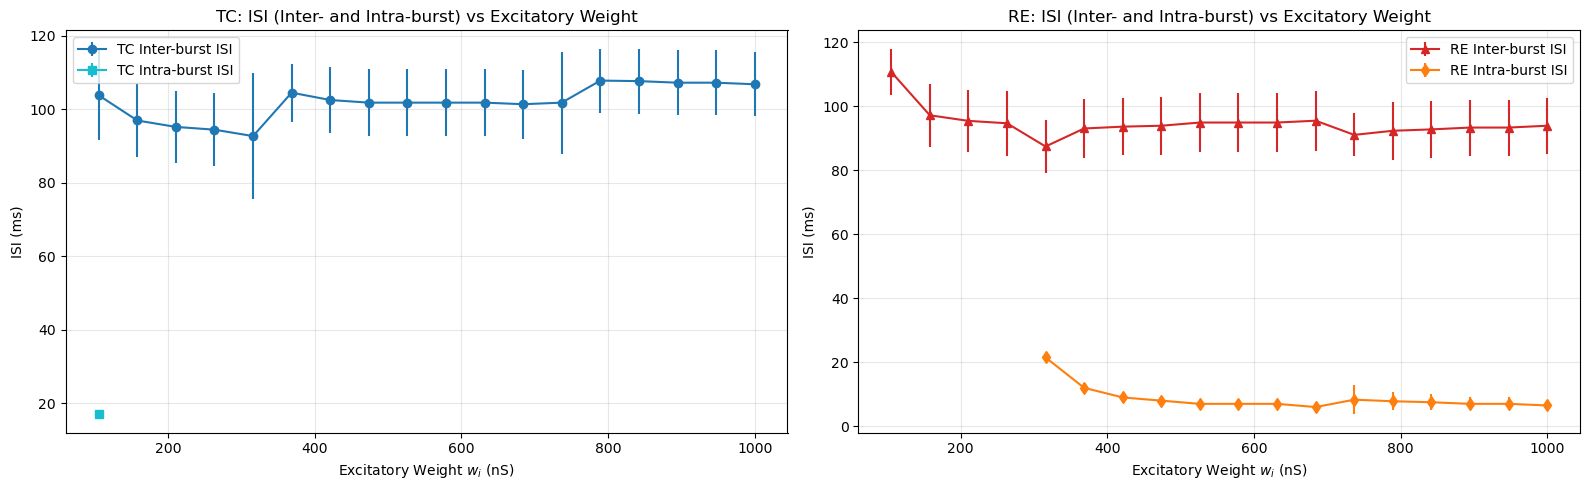

In [9]:
# Plot ISI means vs inhibitory weight for TC and RE in a two-panel subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

# TC subplot
axes[0].errorbar(w_i_values, tc_inter_burst_isi_means, yerr=tc_inter_burst_isi_stds, label="TC Inter-burst ISI", marker='o', color='tab:blue')
axes[0].errorbar(w_i_values, tc_intra_burst_isi_means, yerr=tc_intra_burst_isi_stds, label="TC Intra-burst ISI", marker='s', color='tab:cyan')
axes[0].set_xlabel("Excitatory Weight $w_i$ (nS)")
axes[0].set_ylabel("ISI (ms)")
axes[0].set_title("TC: ISI (Inter- and Intra-burst) vs Excitatory Weight")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RE subplot
axes[1].errorbar(w_i_values, re_inter_burst_isi_means, yerr=re_inter_burst_isi_stds, label="RE Inter-burst ISI", marker='^', color='tab:red')
axes[1].errorbar(w_i_values, re_intra_burst_isi_means, yerr=re_intra_burst_isi_stds, label="RE Intra-burst ISI", marker='d', color='tab:orange')
axes[1].set_xlabel("Excitatory Weight $w_i$ (nS)")
axes[1].set_ylabel("ISI (ms)")
axes[1].set_title("RE: ISI (Inter- and Intra-burst) vs Excitatory Weight")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
v1_array = []
rate_array = []
tau_syn_ex_array = np.round(np.linspace(2, 6, 10), 1)
tau_syn_in_array = np.round(np.linspace(15, 20, 5), 1)

for i in tau_syn_ex_array:
    for k in tau_syn_in_array:
        neuron_dicts['TC']["tau_syn_ex"] = i
        neuron_dicts['RE']["tau_syn_ex"] = i
        neuron_dicts['TC']["tau_syn_in"] = k
        neuron_dicts['RE']["tau_syn_in"] = k
        sim_output= sim(sim_params, neuron_dicts, syn_params, current_params)
        voltmeter1 = sim_output["voltmeters"][0]
        voltmeter2 = sim_output["voltmeters"][1]
        spikemeter1 = sim_output["spikemeters"][0]
        spikemeter2 = sim_output["spikemeters"][1]
        
        TC_data = nest.GetStatus(voltmeter1)[0]
        RE_data = nest.GetStatus(voltmeter2)[0]
        times = TC_data["events"]["times"]
        voltages = TC_data["events"]["V_m"]
        times2 = RE_data["events"]["times"]
        voltages2 = RE_data["events"]["V_m"]
        spikes=sum(spikemeter1.get("events")["senders"])
        spikes2=sum(spikemeter2.get("events")["senders"])
        rate = spikes/1
        rate2 = spikes2/1
        rate_array.append(rate)
        data= {"times": times, "voltages": voltages, "times2": times2, "voltages2": voltages2, "tau_syn_ex": i, "tau_syn_in": k}
        v1_array.append(data)






Feb 12 17:20:10 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:10 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:10 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Feb 12 17:20:10 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.

Feb 12 17:20:10 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Feb 12 17:20:10 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Feb 12 17:20:10 SimulationManager::run [Info]: 
    Simulation finished.

Feb 12 17:20:10 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:10 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 12 17:20:10 correlospinmatrix_detector [Info]: 
    D

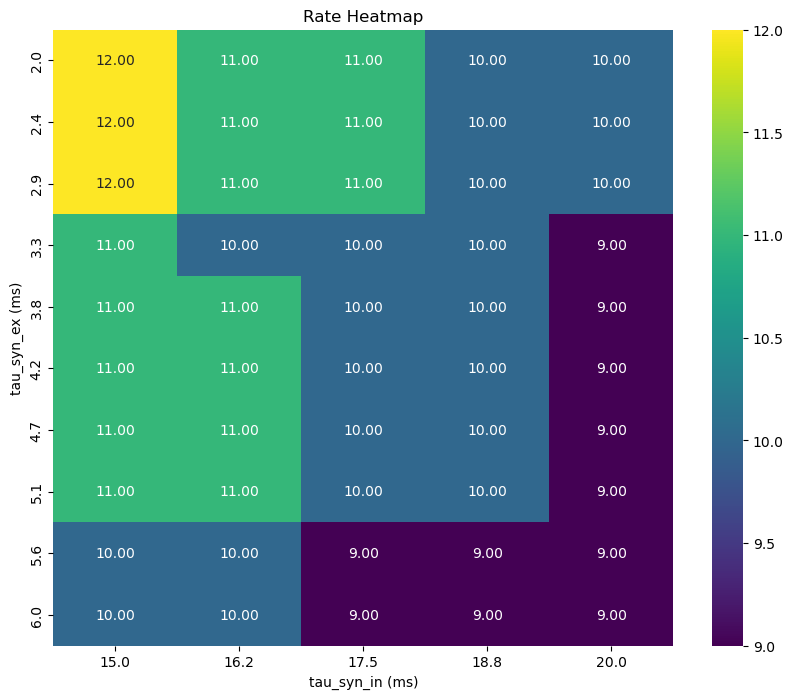

<Figure size 640x480 with 0 Axes>

In [ ]:
def plot_rate_heatmap(rate_array, tau_syn_ex_array, tau_syn_in_array):
    # Reshape the rate array into a 2D array for the heatmap
    rate_matrix = np.array(rate_array).reshape(len(tau_syn_ex_array), len(tau_syn_in_array))
    # Create a heatmap using seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(rate_matrix, annot=True, fmt=".2f", xticklabels=tau_syn_in_array, yticklabels=tau_syn_ex_array, cmap="viridis")
    plt.xlabel("tau_syn_in (ms)")
    plt.ylabel("tau_syn_ex (ms)")
    plt.title("Rate Heatmap")
    plt.show()

plot_rate_heatmap(rate_array, tau_syn_ex_array, tau_syn_in_array)


plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the title
plt.show()


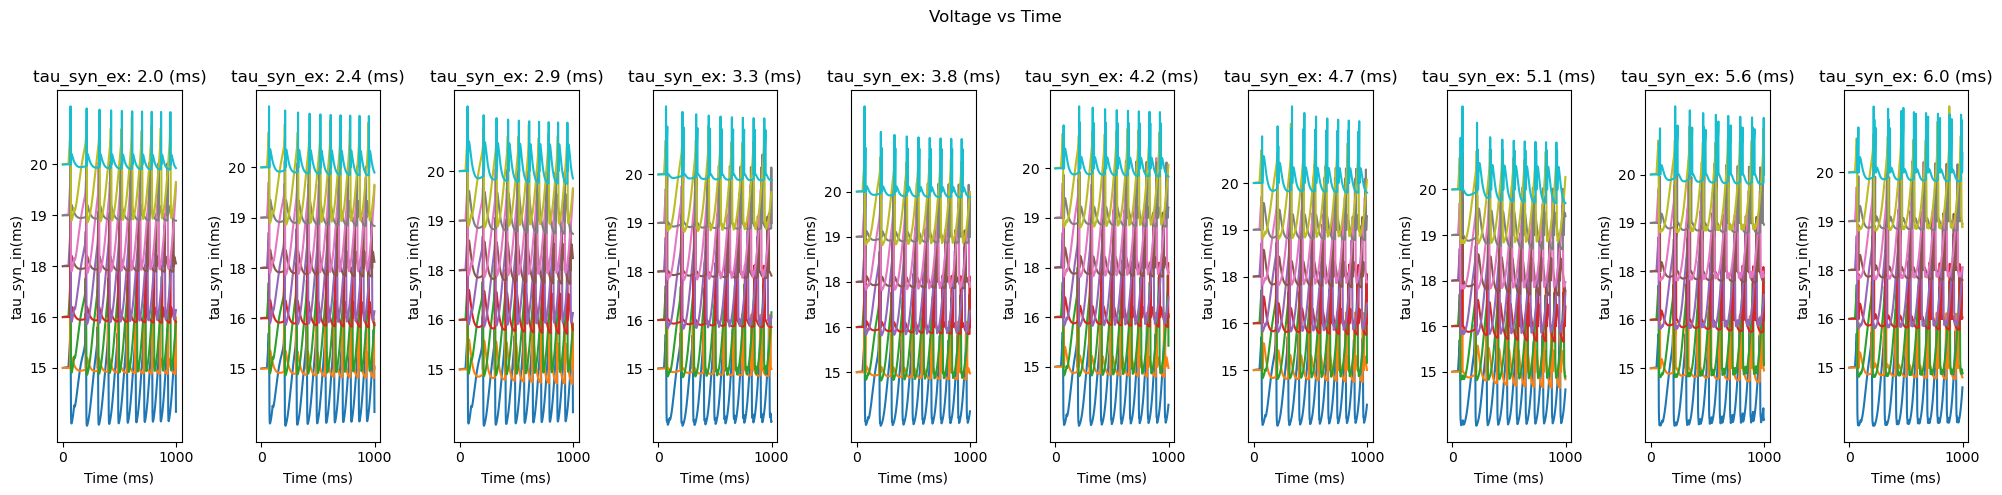

In [12]:
x_plots = len(tau_syn_ex_array)
fig, axes = plt.subplots(1, x_plots, figsize=(20, 5))
fig.suptitle("Voltage vs Time")

# If there's only one subplot, `axes` will not be an array, so we need to handle that case
if x_plots == 1:
    axes = [axes]

for i, tau_syn_ex in enumerate(tau_syn_ex_array):
    ax = axes[i]
    k = -20
    yticks = []
    ytick_labels = []
    for data in v1_array:
        k = k + 20
        if data["tau_syn_ex"] == tau_syn_ex:
            ax.plot(data["times"], data["voltages"] + k, label=f"TC tau_syn_in: {data['tau_syn_in']}")
            ax.plot(data["times2"], data["voltages2"] + k, label=f"RE tau_syn_in: {data['tau_syn_in']}")
            yticks.append(k-60)
            ytick_labels.append(round(data["tau_syn_in"]))
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_ylabel("tau_syn_in(ms)")
    ax.set_xlabel("Time (ms)")
    ax.set_title(f"tau_syn_ex: {tau_syn_ex} (ms)")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the title
plt.show()



Simulate

In [ ]:

# Get the data from the spikemeter
events1 = spikemeter1.get("events")
events2 = spikemeter2.get("events")
sendes1 = events1["senders"]
times1 = events1["times"]
sendes2 = events2["senders"]
times2 = events2["times"]
sendes3 = events3["senders"]
times3 = events3["times"]


# Combine the data into a single DataFrame for seaborn
df1 = pd.DataFrame({'Time': times1, 'Neuron': sendes1, 'Type': 'Noise'})
df2 = pd.DataFrame({'Time': times2, 'Neuron': sendes2, 'Type': 'TC'})
df3 = pd.DataFrame({'Time': times3, 'Neuron': sendes3, 'Type': 'RE'})
df_combined = pd.concat([df1, df2, df3])

# Plot the raster plot using seaborn with improved aesthetics
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_combined, x='Time', y='Neuron', hue='Type', palette={ 'Noise':'black','TC': 'blue', 'RE': 'red'}, s=10)
plt.title('Raster Plot of Neuron Spikes')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron ID')
plt.legend(title='Neuron Type')
sns.despine()
plt.show()

